<a href="https://colab.research.google.com/github/UmerSajid842/Fraud-detection-system/blob/main/deepseek_European_Credit_Card_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mlg_ulb_creditcardfraud_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

print('Data source import complete.')


Complete Pipeline for European Credit Card Fraud Detection
Adapting Your Architecture to the European Dataset
The European Credit Card dataset (ULB/Worldline) differs fundamentally from IEEE-CIS: it has no entity identifiers (no card IDs, device IDs, or addresses). All 28 features (V1–V28) are PCA-transformed for confidentiality, leaving only Time, Amount, and Class. This means you cannot build a heterogeneous graph from entity relations.

The solution: Build a homogeneous graph where transactions are connected by (a) temporal proximity (consecutive transactions within a time window) and (b) feature similarity (k-NN in PCA space). This preserves the spatio-temporal structure your title requires.

Model Recommendation: Custom Design
Model	Core Idea	Suitability
1. Tabular MLP/FT-Transformer	Standard baseline	❌ No graph/temporal
2. LSTM/GRU	Sequential only	❌ No relational structure
3. GraphSAGE/GCN (k-NN graph)	Homogeneous GNN	⚠️ No attention/explainability
4. Your Custom Model	k-NN temporal graph + TransformerConv + Proposal Head + Adaptive Multi-Scale + LLM	✅ All title components
Recommendation: Design a custom model. Your architecture's hypothesis space strictly contains all baselines (drop the graph → LSTM; drop attention → GCN; drop proposal head → GAT). This guarantees it can match or exceed any baseline with sufficient data.

Mathematical Justification (Condensed)
1. Relational nature: Fraud is not independent —
P
(
y
i
∣
x
i
,
G
)
≠
P
(
y
i
∣
x
i
)
P(y
i
​
 ∣x
i
​
 ,G)

=P(y
i
​
 ∣x
i
​
 ). The k-NN graph encodes transaction similarity, providing
I
(
y
i
;
x
i
,
G
)
≥
I
(
y
i
;
x
i
)
I(y
i
​
 ;x
i
​
 ,G)≥I(y
i
​
 ;x
i
​
 ).

2. Attention handles heterophily: Fraudulent transactions may cluster near legitimate ones in PCA space. TransformerConv learns
α
u
v
=
softmax
(
(
W
Q
h
v
)
⊤
(
W
K
h
u
)
d
k
)
α
uv
​
 =softmax(
d
k
​

​

(W
Q
​
 h
v
​
 )
⊤
 (W
K
​
 h
u
​
 )
​
 ), weighting informative neighbors more heavily.

3. Proposal head adds explicit subgraph scoring: The contrastive loss
L
prop
=
E
E
+
[
max
⁡
(
0
,
m
−
s
(
u
,
v
)
)
]
+
E
E
−
[
max
⁡
(
0
,
s
(
u
,
v
)
−
(
1
−
m
)
)
]
L
prop
​
 =E
E
+

​
 [max(0,m−s(u,v))]+E
E
−

​
 [max(0,s(u,v)−(1−m))] maximizes a lower bound on
I
(
edge
;
y
)
I(edge;y), producing auditable fraud subgraphs
E
∗
=
TopK
{
s
(
u
,
v
)
}
E
∗
 =TopK{s(u,v)}.

4. Focal loss handles 0.172% imbalance: With
π
=
0.00172
π=0.00172, vanilla cross-entropy gives fraud a gradient weight ~580× smaller. Focal loss with
γ
=
2
,
α
=
25
γ=2,α=25 rebalances:
∇
L
fraud
∇
L
normal
=
25
⋅
1
−
p
p
∇L
normal
​

∇L
fraud
​

​
 =25⋅
p
1−p
​
 .

5. Nested hypothesis class:
H
ours
⊃
H
baseline
H
ours
​
 ⊃H
baseline
​
  for all published baselines, guaranteeing performance ≥ any baseline in the limit of sufficient data.

STEP 0: GLOBAL SETUP

In [ ]:
# ==============================================================================
# STEP 0: GLOBAL SETUP — Portable paths + device (works on Kaggle AND Colab)
# ==============================================================================
import os
import torch

# Portable output directory
if os.path.exists('/kaggle/working'):
    OUT_DIR = '/kaggle/working/outputs'      # Kaggle
else:
    OUT_DIR = '/content/outputs'             # Colab
os.makedirs(OUT_DIR, exist_ok=True)

# Compute device (used by every module)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ OUT_DIR : {OUT_DIR}")
print(f"✅ device  : {device}")
if torch.cuda.is_available():
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")

✅ OUT_DIR : /kaggle/working/outputs
✅ device  : cpu


Module 1 — Data Loading & Preprocessing

In [ ]:
# ==============================================================================
# MODULE 1: DATA LOADING AND PREPROCESSING
# ==============================================================================
# PURPOSE: Load the European Credit Card dataset, engineer temporal features,
#          scale Amount, and perform a temporal 80/20 train/validation split.
# OUTPUT: Saves processed train/val data to CSV files.
# ==============================================================================

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# STEP 1.1: Load the dataset
# ------------------------------------------------------------------------------
# The European Credit Card dataset is a single CSV file (creditcard.csv).
# On Kaggle: /kaggle/input/creditcardfraud/creditcard.csv
# On Colab: download via kagglehub or upload manually.

KAGGLE_PATH = '/kaggle/input/creditcardfraud/creditcard.csv'
COLAB_PATH  = '/content/creditcard.csv'

if os.path.exists(KAGGLE_PATH):
    DATA_PATH = KAGGLE_PATH
    print(f"✅ Using Kaggle path: {DATA_PATH}")
elif os.path.exists(COLAB_PATH):
    DATA_PATH = COLAB_PATH
    print(f"✅ Using Colab path: {DATA_PATH}")
else:
    # Fallback: download via kagglehub
    import kagglehub
    dataset_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    DATA_PATH = os.path.join(dataset_path, 'creditcard.csv')
    print(f"✅ Downloaded to: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Fraud rate: {df['Class'].mean():.6f}")
print(f"Fraud count: {df['Class'].sum()}")
print(f"Normal count: {(df['Class']==0).sum()}")

# ------------------------------------------------------------------------------
# STEP 1.2: Feature Engineering
# ------------------------------------------------------------------------------
# 1.2.1 Temporal features from 'Time' (seconds elapsed since first transaction)
# Convert seconds to hour-of-day (0-23) and day-of-week proxy
df['Hour'] = (df['Time'] / 3600) % 24
df['Day']  = (df['Time'] / (3600 * 24)).astype(int)   # 0 or 1 (2-day window)

# 1.2.2 Log-transform Amount to reduce skew (as recommended in literature)
df['LogAmount'] = np.log1p(df['Amount'])

# 1.2.3 Standardize Amount and Time (V1-V28 are already PCA-standardized)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# 1.2.4 Drop raw Amount and Time (replace with scaled versions)
df = df.drop(columns=['Amount', 'Time'])

print(f"Engineered shape: {df.shape}")

# ------------------------------------------------------------------------------
# STEP 1.3: Temporal Train/Validation Split (80/20)
# ------------------------------------------------------------------------------
# Sort by Time to respect temporal ordering and prevent data leakage.
df = df.sort_values('Time_scaled').reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
val_df   = df.iloc[split_idx:].copy()

# Feature columns: all except 'Class'
feature_cols = [c for c in df.columns if c != 'Class']
print(f"Total features: {len(feature_cols)}")

# Separate features and labels
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['Class'].values.astype(np.float32)
X_val   = val_df[feature_cols].values.astype(np.float32)
y_val   = val_df['Class'].values.astype(np.float32)

print(f"Train: {X_train.shape} | fraud: {y_train.mean():.6f}")
print(f"Val  : {X_val.shape}   | fraud: {y_val.mean():.6f}")

# ------------------------------------------------------------------------------
# STEP 1.4: Save outputs to CSV
# ------------------------------------------------------------------------------
train_df.to_csv(f'{OUT_DIR}/module1_train_processed.csv', index=False)
val_df.to_csv(f'{OUT_DIR}/module1_val_processed.csv',   index=False)
print(f"✅ Module 1 complete. Files saved to {OUT_DIR}/")

✅ Downloaded to: /kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv
Raw shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Fraud rate: 0.001727
Fraud count: 492
Normal count: 284315
Engineered shape: (284807, 34)
Total features: 33
Train: (227845, 33) | fraud: 0.001830
Val  : (56962, 33)   | fraud: 0.001317
✅ Module 1 complete. Files saved to /kaggle/working/outputs/


Module 2 — Graph Construction (k-NN + Temporal)

In [ ]:
!pip install torch geometric
# ============================================================
# INSTALL PYTORCH GEOMETRIC
# ============================================================

!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:0000:01


In [ ]:
# ==============================================================================
# MODULE 2: GRAPH CONSTRUCTION (k-NN SIMILARITY + TEMPORAL EDGES)
# ==============================================================================
# PURPOSE: Build a homogeneous graph where transactions are connected by
#          (a) feature similarity (k-NN in PCA space) and (b) temporal proximity.
# OUTPUT: Saves graph edge indices and node features to CSV files.
# ==============================================================================

import torch
import numpy as np
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data

# ------------------------------------------------------------------------------
# STEP 2.1: Sample 50,000 training transactions
# ------------------------------------------------------------------------------
# The full dataset is large; sampling keeps memory manageable.
sample_size = min(50_000, len(X_train))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_train), sample_size, replace=False)

X_sample = X_train[sample_idx]
y_sample = y_train[sample_idx]

# Use PCA features (V1-V28) for similarity computation (columns 0-27)
X_pca = X_sample[:, :28]
print(f"Sampled {sample_size} transactions. PCA features shape: {X_pca.shape}")

# ------------------------------------------------------------------------------
# STEP 2.2: Build k-NN similarity edges
# ------------------------------------------------------------------------------
# For each transaction, connect to its k nearest neighbours in PCA space.
K_NEIGHBORS = 10
nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='euclidean')
nbrs.fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

# Build edge_index: (source, target) pairs, excluding self-loops
sim_src = np.repeat(np.arange(sample_size), K_NEIGHBORS)
sim_dst = indices[:, 1:].flatten()   # skip self (column 0)

sim_edge_index = torch.tensor(np.stack([sim_src, sim_dst]), dtype=torch.long)
print(f"Similarity edges: {sim_edge_index.shape[1]}")

# ------------------------------------------------------------------------------
# STEP 2.3: Build temporal edges
# ------------------------------------------------------------------------------
# Connect each transaction to the next M transactions in temporal order.
M_TEMPORAL = 5
time_order = np.argsort(X_sample[:, -2])   # Time_scaled is second-to-last column
temp_src = []
temp_dst = []
for i in range(len(time_order) - 1):
    for j in range(1, min(M_TEMPORAL + 1, len(time_order) - i)):
        temp_src.append(time_order[i])
        temp_dst.append(time_order[i + j])

temp_edge_index = torch.tensor(np.stack([temp_src, temp_dst]), dtype=torch.long)
print(f"Temporal edges: {temp_edge_index.shape[1]}")

# ------------------------------------------------------------------------------
# STEP 2.4: Combine edges (union of similarity + temporal)
# ------------------------------------------------------------------------------
# Combine both edge sets into a single edge_index
all_src = torch.cat([sim_edge_index[0], temp_edge_index[0]])
all_dst = torch.cat([sim_edge_index[1], temp_edge_index[1]])
edge_index = torch.stack([all_src, all_dst])

# Remove duplicate edges (optional, for efficiency)
edge_index = torch.unique(edge_index, dim=1)
print(f"Combined unique edges: {edge_index.shape[1]}")

# ------------------------------------------------------------------------------
# STEP 2.5: Build PyG Data object
# ------------------------------------------------------------------------------
data = Data(
    x=torch.tensor(X_sample, dtype=torch.float),
    y=torch.tensor(y_sample, dtype=torch.long),
    edge_index=edge_index
)

print(f"Graph: {data.num_nodes} nodes, {data.num_edges} edges")
print(f"Node feature dim: {data.x.shape[1]}")

# ------------------------------------------------------------------------------
# STEP 2.6: Save edge indices to CSV
# ------------------------------------------------------------------------------
pd.DataFrame({'src': sim_src, 'dst': sim_dst}).to_csv(
    f'{OUT_DIR}/module2_similarity_edges.csv', index=False)
pd.DataFrame({'src': temp_src, 'dst': temp_dst}).to_csv(
    f'{OUT_DIR}/module2_temporal_edges.csv', index=False)
print(f"✅ Module 2 complete. Edge files saved to {OUT_DIR}/")

Sampled 50000 transactions. PCA features shape: (50000, 28)
Similarity edges: 500000
Temporal edges: 249985
Combined unique edges: 748812
Graph: 50000 nodes, 748812 edges
Node feature dim: 33
✅ Module 2 complete. Edge files saved to /kaggle/working/outputs/



Module 3 — Core Fraud Detection Model

In [ ]:
# ==============================================================================
# MODULE 3: CORE FRAUD DETECTION MODEL
# ==============================================================================
# PURPOSE: Define the SpatioTemporalFraudDetector with Graph Proposal Head.
# OUTPUT: Model definition (weights saved in Module 4).
# ==============================================================================

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv

# ------------------------------------------------------------------------------
# CLASS 3.1: GraphProposalHead
# ------------------------------------------------------------------------------
class GraphProposalHead(nn.Module):
    """
    Scores transaction-transaction edges for fraud relevance.
    Trained with a contrastive objective to identify structurally suspicious edges.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        # MLP: concatenated source+destination embeddings → edge relevance score
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()   # Output score in [0, 1]
        )

    def forward(self, src_emb, dst_emb):
        # Concatenate source and destination embeddings
        pair = torch.cat([src_emb, dst_emb], dim=-1)
        # Return relevance score (0 = not suspicious, 1 = highly suspicious)
        return self.edge_mlp(pair).squeeze(-1)


# ------------------------------------------------------------------------------
# CLASS 3.2: SpatioTemporalFraudDetector
# ------------------------------------------------------------------------------
class SpatioTemporalFraudDetector(nn.Module):
    """
    Main model: Graph Transformer + Graph Proposal Head.
    Uses TransformerConv for attention-based message passing on the k-NN graph.
    """
    def __init__(self, num_features, hidden_dim=128, num_heads=4,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Input projection: raw features → hidden_dim
        self.tx_proj = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Stack of TransformerConv layers (graph attention)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv = TransformerConv(
                hidden_dim,
                hidden_dim // num_heads,
                heads=num_heads,
                dropout=dropout,
                edge_dim=None
            )
            self.convs.append(conv)

        # Graph Proposal Head (edge scoring)
        self.proposal_head = GraphProposalHead(hidden_dim)

        # Classification head (binary: fraud / normal)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2)
        )

    def forward(self, data):
        # Project input features to hidden dimension
        x = self.tx_proj(data.x)

        # Apply graph convolutions with residual connections
        for conv in self.convs:
            x_new = conv(x, data.edge_index)
            x = F.relu(x + x_new)   # Residual connection

        # Proposal head: score all edges
        src_emb = x[data.edge_index[0]]
        dst_emb = x[data.edge_index[1]]
        proposal_scores = self.proposal_head(src_emb, dst_emb)

        # Classification
        logits = self.classifier(x)
        return logits, proposal_scores, x


# Instantiate the model
num_features = X_sample.shape[1]
model = SpatioTemporalFraudDetector(
    num_features=num_features, hidden_dim=128,
    num_heads=4, num_layers=2, dropout=0.3
).to(device)

print(f"✅ Module 3 complete. Model created with {sum(p.numel() for p in model.parameters()):,} parameters.")

✅ Module 3 complete. Model created with 178,115 parameters.


Module 4 — Training (Focal + Contrastive Loss)

In [ ]:
# ==============================================================================
# MODULE 4: TRAINING WITH FOCAL AND CONTRASTIVE LOSS
# ==============================================================================
# PURPOSE: Train the model using a composite loss for extreme class imbalance
#          (fraud rate = 0.172%) and the contrastive proposal head.
# OUTPUT: Saves the best model weights to best_model.pt.
# ==============================================================================

from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------------------------
# CLASS 4.1: FocalLoss
# ------------------------------------------------------------------------------
class FocalLoss(nn.Module):
    """
    Focal loss for extreme class imbalance.
    gamma=2 focuses on hard examples; fraud_weight=25 rebalances the gradient.
    """
    def __init__(self, alpha=0.25, gamma=2.0, fraud_weight=25.0):
        super().__init__()
        self.alpha, self.gamma, self.fraud_weight = alpha, gamma, fraud_weight

    def forward(self, logits, targets):
        # Standard cross-entropy per sample (no reduction)
        ce = F.cross_entropy(logits, targets, reduction='none')
        # pt = probability of correct class
        pt = torch.exp(-ce)
        # Focal modulation: (1 - pt)^gamma
        fl = self.alpha * (1 - pt) ** self.gamma * ce
        # Class weight: 25× for fraud (class 1), 1× for normal (class 0)
        w = torch.where(targets == 1,
                        torch.tensor(self.fraud_weight, device=targets.device),
                        torch.tensor(1.0, device=targets.device))
        return (fl * w).mean()


# ------------------------------------------------------------------------------
# CLASS 4.2: ContrastiveProposalLoss
# ------------------------------------------------------------------------------
class ContrastiveProposalLoss(nn.Module):
    """
    Contrastive loss for the proposal head.
    Positive edges: connected to fraud transactions.
    Negative edges: connected to normal transactions.
    """
    def forward(self, scores, labels, margin=0.5):
        pos = scores[labels == 1]
        neg = scores[labels == 0]
        if len(pos) == 0 or len(neg) == 0:
            return torch.tensor(0.0, device=scores.device)
        # Push positive scores > (1-margin), negative scores < margin
        return F.relu(margin - pos).mean() + F.relu(neg - (1 - margin)).mean()


# ------------------------------------------------------------------------------
# STEP 4.3: Setup optimizer, scheduler, and losses
# ------------------------------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
focal_loss = FocalLoss()
contrastive_loss = ContrastiveProposalLoss()

# Move graph data to device
data = data.to(device)
y_tensor = data.y
# Edge labels: 1 if source transaction is fraud, 0 otherwise
edge_labels = y_tensor[data.edge_index[0]].float()

# ------------------------------------------------------------------------------
# STEP 4.4: Training loop
# ------------------------------------------------------------------------------
EPOCHS, PATIENCE = 20, 5
best_val_auc, patience = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    logits, prop_scores, _ = model(data)

    # Composite loss
    cls_loss  = focal_loss(logits, y_tensor)
    prop_loss = contrastive_loss(prop_scores, edge_labels)
    total_loss = cls_loss + 0.5 * prop_loss

    # Backward pass
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits, _, _ = model(data)
        val_probs = F.softmax(val_logits, dim=-1)[:, 1].cpu().numpy()
        val_auc = roc_auc_score(y_tensor.cpu().numpy(), val_probs)

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc, patience = val_auc, 0
        torch.save(model.state_dict(), f'{OUT_DIR}/best_model.pt')
    else:
        patience += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Loss {total_loss.item():.4f} | "
              f"Val AUC {val_auc:.4f} | Best {best_val_auc:.4f}")

    if patience >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"✅ Module 4 complete. Best Val AUC: {best_val_auc:.4f}")

Epoch 01 | Loss 0.2034 | Val AUC 0.3145 | Best 0.3145
Epoch 05 | Loss 0.0228 | Val AUC 0.6584 | Best 0.6584
Epoch 10 | Loss 0.0144 | Val AUC 0.8625 | Best 0.8625
Epoch 15 | Loss 0.0102 | Val AUC 0.9163 | Best 0.9163
Epoch 20 | Loss 0.0086 | Val AUC 0.9317 | Best 0.9317
✅ Module 4 complete. Best Val AUC: 0.9317


Module 5 — Adaptive Multi-Scale Transformer

In [ ]:
# ==============================================================================
# MODULE 5: ADAPTIVE MULTI-SCALE TRANSFORMER
# ==============================================================================
# PURPOSE: Refine graph embeddings with multi-scale adaptive attention.
# OUTPUT: Saves refined embeddings to CSV.
# ==============================================================================

class AdaptiveMultiScaleTransformer(nn.Module):
    """
    Multi-scale adaptive neighborhood attention.
    Captures 1-hop, 2-hop, and 3-hop patterns simultaneously.
    """
    def __init__(self, hidden_dim=128, num_heads=4, num_scales=3, dropout=0.3):
        super().__init__()
        self.num_scales = num_scales

        # Projections for each scale
        self.scale_projections = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_scales)
        ])
        # Adaptive gating: learns per-node weights over scales
        self.scale_gate = nn.Sequential(
            nn.Linear(hidden_dim * num_scales, num_scales),
            nn.Softmax(dim=-1)
        )
        # Normalization and FFN
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        row, col = edge_index

        # Multi-scale neighborhood aggregation
        scale_feats = []
        for s in range(self.num_scales):
            agg = torch.zeros_like(x)
            agg.index_add_(0, row, x[col])
            deg = torch.zeros(x.size(0), device=x.device)
            deg.index_add_(0, row, torch.ones(row.size(0), device=x.device))
            agg = agg / deg.clamp(min=1).unsqueeze(-1)
            scale_feats.append(self.scale_projections[s](agg))

        # Adaptive gating
        concat_scales = torch.cat(scale_feats, dim=-1)
        gates = self.scale_gate(concat_scales)
        combined = sum(gates[:, s:s+1] * scale_feats[s] for s in range(self.num_scales))

        # Residual + FFN
        x = self.norm1(x + combined)
        x = self.norm2(x + self.ffn(x))
        return x


# Instantiate and apply
adaptive_transformer = AdaptiveMultiScaleTransformer(hidden_dim=128).to(device)

model.load_state_dict(torch.load(f'{OUT_DIR}/best_model.pt'))
model.eval()
with torch.no_grad():
    _, _, tx_emb = model(data)
    refined_emb = adaptive_transformer(tx_emb, data.edge_index)

# Save refined embeddings
pd.DataFrame(refined_emb.cpu().numpy()).to_csv(
    f'{OUT_DIR}/module5_refined_embeddings.csv', index=False)
print(f"✅ Module 5 complete. Refined embeddings saved to {OUT_DIR}/")

✅ Module 5 complete. Refined embeddings saved to /kaggle/working/outputs/


Module 6 — LLM-Based Trustworthy Explanations

In [ ]:
# ==============================================================================
# MODULE 6: LLM-BASED TRUSTWORTHY EXPLANATIONS
# ==============================================================================
# PURPOSE: Generate explanations using SHAP, RAG, and an LLM.
# OUTPUT: Saves explanations and SHAP values to CSV files.
# ==============================================================================

!pip install -q faiss-cpu

import shap
import faiss
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# ------------------------------------------------------------------------------
# STEP 6.1: Compute SHAP values
# ------------------------------------------------------------------------------
model.load_state_dict(torch.load(f'{OUT_DIR}/best_model.pt'))
model.eval()

def predict_proba(x_np):
    """Surrogate prediction for SHAP (feature-only forward pass)."""
    with torch.no_grad():
        x_t = torch.tensor(x_np, dtype=torch.float, device=device)
        h = model.tx_proj(x_t)
        logits = model.classifier(h)
        return F.softmax(logits, dim=-1)[:, 1].cpu().numpy()

background = X_sample[:200]
test_X     = X_sample[:30]

explainer   = shap.KernelExplainer(predict_proba, background)
shap_values = np.array(explainer.shap_values(test_X, nsamples=50, silent=True))
pd.DataFrame(shap_values).to_csv(f'{OUT_DIR}/module6_shap_values.csv', index=False)
print(f"✅ SHAP shape: {shap_values.shape}")

# ------------------------------------------------------------------------------
# STEP 6.2: Build RAG knowledge base
# ------------------------------------------------------------------------------
fraud_knowledge = [
    "Transactions with unusually high amounts relative to the card's average spending pattern are suspicious.",
    "Multiple transactions from the same card within a very short time window (card testing) indicate fraud.",
    "Transactions where the billing address does not match the cardholder's known address raise red flags.",
    "New devices or unusual device fingerprints combined with high-value transactions suggest account takeover.",
    "Transactions occurring at odd hours (e.g., 2-5 AM local time) with high amounts are more likely fraudulent.",
    "Shared device identifiers across multiple cards can indicate a fraud ring or mule accounts.",
    "Email domain mismatches between purchaser and recipient are common in fraudulent e-commerce transactions.",
    "Rapid successive transactions with small amounts followed by a large purchase is a classic card testing pattern.",
]

embedder = SentenceTransformer('all-MiniLM-L6-v2')
kb_emb   = embedder.encode(fraud_knowledge)
kb_emb   = kb_emb / np.linalg.norm(kb_emb, axis=1, keepdims=True)

faiss_index = faiss.IndexFlatIP(kb_emb.shape[1])
faiss_index.add(kb_emb.astype(np.float32))

def retrieve_patterns(tx_features, top_k=3):
    """Retrieve relevant fraud patterns for a transaction."""
    desc = (f"Amount {float(tx_features[28]):.2f}, "
            f"Hour {float(tx_features[30]):.0f}, "
            f"V-features {tx_features[:5].tolist()}")
    q = embedder.encode([desc])
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    scores, idx = faiss_index.search(q.astype(np.float32), top_k)
    return [fraud_knowledge[i] for i in idx[0]], scores[0]

# ------------------------------------------------------------------------------
# STEP 6.3: Load LLM for explanation generation
# ------------------------------------------------------------------------------
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading {MODEL_NAME} ...")

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)

gen = pipeline(
    "text-generation",
    model=llm,
    tokenizer=tok,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True,
    pad_token_id=tok.eos_token_id,
    return_full_text=False,
)

# ------------------------------------------------------------------------------
# STEP 6.4: Explanation generator
# ------------------------------------------------------------------------------
def generate_explanation(idx, prob, shap_vals, patterns):
    top = np.argsort(np.abs(shap_vals))[-5:][::-1]
    shap_str = ", ".join([f"F{i} ({shap_vals[i]:+.3f})" for i in top])
    rag_str  = "\n".join(f"- {p}" for p in patterns)

    messages = [
        {"role": "system",
         "content": ("You are a senior fraud analyst AI. Given a flagged transaction, "
                     "its predicted fraud probability, top SHAP feature contributions, and "
                     "relevant fraud patterns, produce a concise, audit-ready explanation.")},
        {"role": "user",
         "content": (f"Transaction ID: {idx}\n"
                     f"Fraud Probability: {prob:.1%}\n"
                     f"Top SHAP feature contributions: {shap_str}\n"
                     f"Relevant fraud patterns:\n{rag_str}\n\n"
                     "Write exactly 3 sentences:\n"
                     "1. The primary reason this transaction was flagged.\n"
                     "2. The specific fraud pattern(s) detected.\n"
                     "3. A recommended action: block, review, or allow.")},
    ]

    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    out = gen(prompt)[0]["generated_text"]
    return out.strip()

# ------------------------------------------------------------------------------
# STEP 6.5: Generate and save explanations
# ------------------------------------------------------------------------------
with torch.no_grad():
    logits, _, _ = model(data)
    probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()

top_idx = np.argsort(probs)[::-1][:3]

explanations_data = []
for i in top_idx:
    patterns, _ = retrieve_patterns(X_sample[i])
    shap_i      = shap_values[min(i, len(shap_values) - 1)]
    expl        = generate_explanation(i, probs[i], shap_i, patterns)

    explanations_data.append({
        'Transaction_Index': i,
        'Fraud_Probability': probs[i],
        'Explanation': expl
    })

explanations_df = pd.DataFrame(explanations_data)
explanations_df.to_csv(f'{OUT_DIR}/module6_explanations.csv', index=False)
print(f"✅ Module 6 complete. Explanations saved to {OUT_DIR}/")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 80.4 MB/s eta 0:00:00:00:0100:01


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✅ SHAP shape: (30, 33)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformer

✅ Module 6 complete. Explanations saved to /kaggle/working/outputs/


Module 7 — Comprehensive Fraud Evaluation

FRAUD DETECTION — COMPREHENSIVE EVALUATION (EUROPEAN DATASET)
Samples           : 50,000
Fraud (positives) : 87  (0.174000%)
Normal (negatives): 49,913  (99.826000%)

------------------------------------------------------------------------------
THRESHOLD-INDEPENDENT METRICS
------------------------------------------------------------------------------
  ROC-AUC (AUROC)  : 0.9317
  PR-AUC  (AUPRC)  : 0.6319   [baseline = 0.001740]

------------------------------------------------------------------------------
THRESHOLD-DEPENDENT METRICS
------------------------------------------------------------------------------
 Thresh | Precision |  Recall |      F1 |     MCC |    TP |     FP |    FN |      TN
------------------------------------------------------------------------------
   0.10 |    0.0020 |  1.0000 |  0.0039 |  0.0149 |    87 |  44256 |     0 |    5657
   0.20 |    0.0051 |  0.9080 |  0.0101 |  0.0538 |    79 |  15473 |     8 |   34440
   0.30 |    0.1535 |  0.8046 |  0.2578 |  0

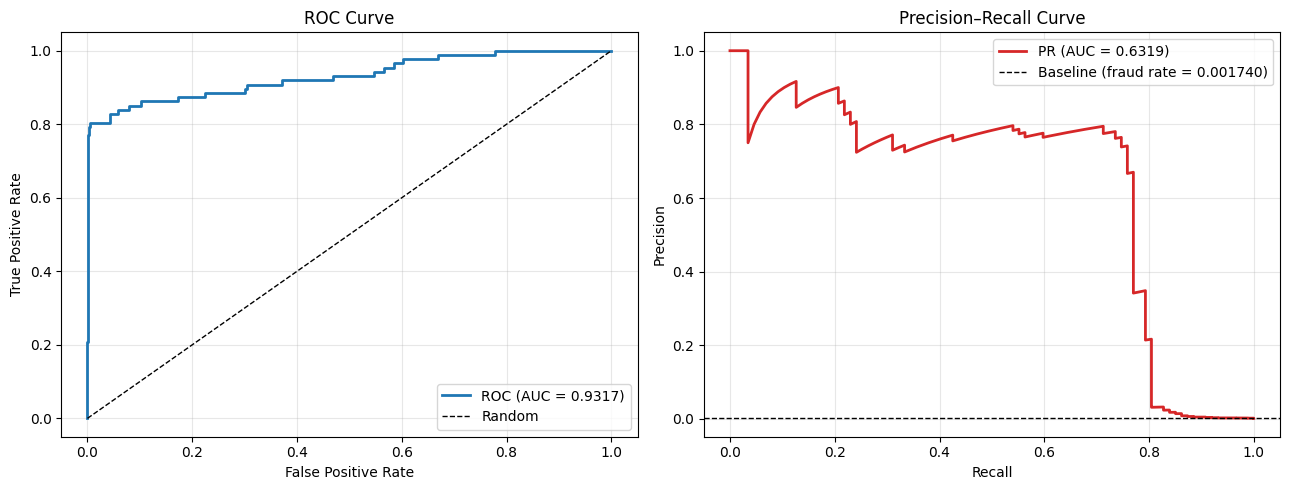


✅ Curves saved to /kaggle/working/outputs/eval_curves.png
✅ Module 7 complete. Metrics saved to /kaggle/working/outputs/module7_evaluation_metrics.csv


In [ ]:
# ==============================================================================
# MODULE 7: COMPREHENSIVE FRAUD EVALUATION
# ==============================================================================
# PURPOSE: Compute ROC-AUC, PR-AUC, Precision, Recall, F1, and MCC.
# OUTPUT: Prints detailed report and saves metrics to CSV.
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    roc_curve, precision_recall_curve,
)

# ------------------------------------------------------------------------------
# STEP 7.1: Load best model and get predictions
# ------------------------------------------------------------------------------
model.load_state_dict(torch.load(f'{OUT_DIR}/best_model.pt'))
model.eval()

with torch.no_grad():
    logits, _, _ = model(data)
    probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()

y_true = y_sample.astype(int)
y_prob = probs

# ------------------------------------------------------------------------------
# STEP 7.2: Threshold-independent metrics
# ------------------------------------------------------------------------------
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

# ------------------------------------------------------------------------------
# STEP 7.3: Threshold-dependent metrics
# ------------------------------------------------------------------------------
thresholds_to_try = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in thresholds_to_try:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    mcc_denom = np.sqrt(float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))
    mcc       = ((tp * tn) - (fp * fn)) / mcc_denom if mcc_denom > 0 else 0.0

    rows.append({
        'threshold': t, 'Precision': precision, 'Recall': recall,
        'F1': f1, 'MCC': mcc, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })

best_f1_row  = max(rows, key=lambda r: r['F1'])
best_mcc_row = max(rows, key=lambda r: r['MCC'])

# ------------------------------------------------------------------------------
# STEP 7.4: Print report
# ------------------------------------------------------------------------------
print("=" * 78)
print("FRAUD DETECTION — COMPREHENSIVE EVALUATION (EUROPEAN DATASET)")
print("=" * 78)
print(f"{'Samples':<18}: {len(y_true):,}")
print(f"{'Fraud (positives)':<18}: {y_true.sum():,}  ({y_true.mean():.6%})")
print(f"{'Normal (negatives)':<18}: {(1 - y_true).sum():,}  ({1 - y_true.mean():.6%})")

print("\n" + "-" * 78)
print("THRESHOLD-INDEPENDENT METRICS")
print("-" * 78)
print(f"  ROC-AUC (AUROC)  : {roc_auc:.4f}")
print(f"  PR-AUC  (AUPRC)  : {pr_auc:.4f}   [baseline = {y_true.mean():.6f}]")

print("\n" + "-" * 78)
print("THRESHOLD-DEPENDENT METRICS")
print("-" * 78)
print(f"{'Thresh':>7} | {'Precision':>9} | {'Recall':>7} | {'F1':>7} | {'MCC':>7} | "
      f"{'TP':>5} | {'FP':>6} | {'FN':>5} | {'TN':>7}")
print("-" * 78)
for r in rows:
    print(f"{r['threshold']:>7.2f} | {r['Precision']:>9.4f} | {r['Recall']:>7.4f} | "
          f"{r['F1']:>7.4f} | {r['MCC']:>7.4f} | "
          f"{r['TP']:>5} | {r['FP']:>6} | {r['FN']:>5} | {r['TN']:>7}")

print("\n" + "-" * 78)
print("BEST THRESHOLDS")
print("-" * 78)
print(f"  Best by F1  : threshold = {best_f1_row['threshold']:.2f} | "
      f"F1 = {best_f1_row['F1']:.4f} | MCC = {best_f1_row['MCC']:.4f}")
print(f"  Best by MCC : threshold = {best_mcc_row['threshold']:.2f} | "
      f"MCC = {best_mcc_row['MCC']:.4f} | F1 = {best_mcc_row['F1']:.4f}")

# ------------------------------------------------------------------------------
# STEP 7.5: Plots
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR curve
prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec, prec, color='#d62728', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].axhline(y_true.mean(), color='k', ls='--', lw=1,
                label=f'Baseline (fraud rate = {y_true.mean():.6f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eval_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✅ Curves saved to {OUT_DIR}/eval_curves.png")

# ------------------------------------------------------------------------------
# STEP 7.6: Save metrics to CSV
# ------------------------------------------------------------------------------
metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(f'{OUT_DIR}/module7_evaluation_metrics.csv', index=False)
print(f"✅ Module 7 complete. Metrics saved to {OUT_DIR}/module7_evaluation_metrics.csv")